先粗筛后精分

In [2]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from IPython.display import Image, display
import os

load_dotenv()
API_KEY = os.getenv("SILICON_API_KEY")
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)


def display_graph(app):
    # 使用 Graphviz 渲染（Colab 最稳定的方案）
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

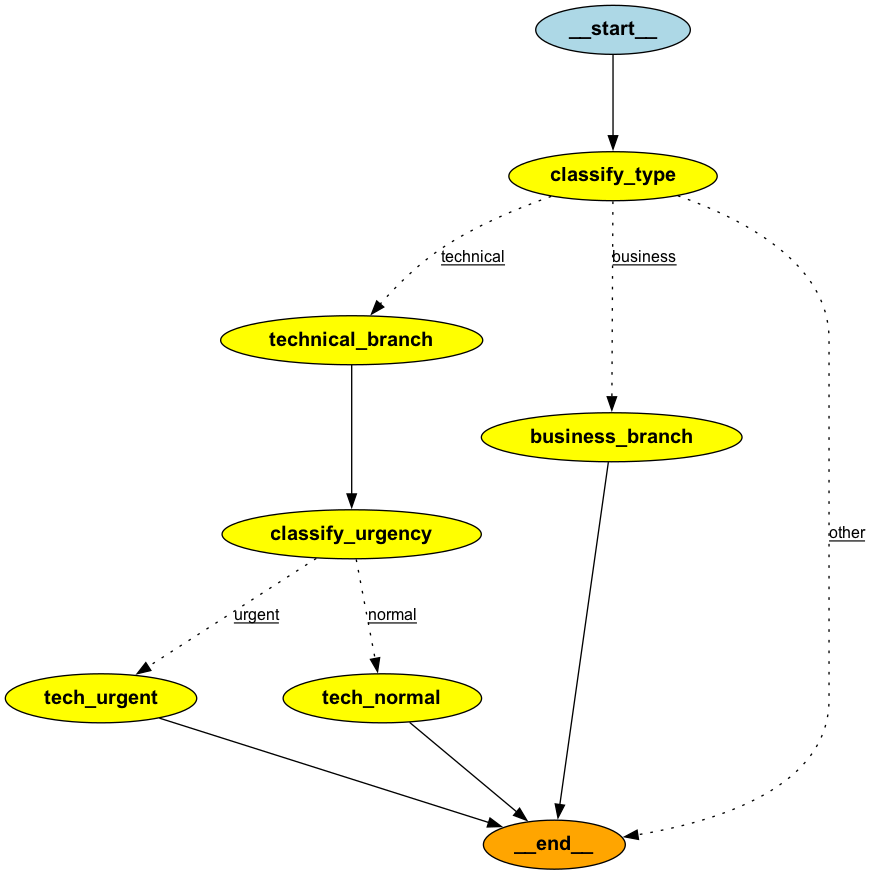

In [3]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from typing import TypedDict, Literal


class MultiLevelState(TypedDict):
    content_type: str
    urgency: str
    assigned_team: str

def classify_content_type(state: MultiLevelState) -> Literal["technical", "business", "other"]:
    """第一级：内容类型分类"""
    # 实际应用中使用 LLM
    return "technical"

def classify_urgency(state: MultiLevelState) -> Literal["urgent", "normal"]:
    """第二级：紧急程度分类"""
    return "urgent"

def assign_technical_urgent(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术紧急响应组"}

def assign_technical_normal(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术支持组"}

# 构建多级路由图
graph = StateGraph(MultiLevelState)

# 第一级分类
graph.add_node("classify_type", lambda s: {})
graph.add_node("technical_branch", lambda s: {})
graph.add_node("business_branch", lambda s: {})

# 第二级分类（technical 分支）
graph.add_node("classify_urgency", lambda s: {})
graph.add_node("tech_urgent", assign_technical_urgent)
graph.add_node("tech_normal", assign_technical_normal)

graph.add_edge(START, "classify_type")
graph.add_conditional_edges(
    "classify_type",
    classify_content_type,
    {
        "technical": "technical_branch",
        "business": "business_branch",
        "other": END
    }
)

graph.add_edge("technical_branch", "classify_urgency")
graph.add_conditional_edges(
    "classify_urgency",
    classify_urgency,
    {
        "urgent": "tech_urgent",
        "normal": "tech_normal"
    }
)

graph.add_edge("tech_urgent", END)
graph.add_edge("tech_normal", END)
graph.add_edge("business_branch", END)

app = graph.compile()
display_graph(app)